<a href="https://colab.research.google.com/github/khalilhaddad7/Diabetes-Prediction-using-Machine-Learning/blob/main/Diabetes%20Prediction%20using%20Machine%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score
from sklearn.metrics import log_loss
Y_actual = [1,1,0,1,0,0,1,0,0,0]
Y_predic = [1,0,1,1,1,0,1,1,0,0]
results = confusion_matrix(Y_actual, Y_predic)
print('confusion Matrix')
print(results)
print('Accuracy Score is',accuracy_score(Y_actual, Y_predic))
print('Classification Report : ')
print(classification_report(Y_actual, Y_predic))
print('AUC-ROC:',roc_auc_score(Y_actual, Y_predic))
print('LOGLOSS value is',log_loss(Y_actual, Y_predic))

confusion Matrix
[[3 3]
 [1 3]]
Accuracy Score is 0.6
Classification Report : 
              precision    recall  f1-score   support

           0       0.75      0.50      0.60         6
           1       0.50      0.75      0.60         4

    accuracy                           0.60        10
   macro avg       0.62      0.62      0.60        10
weighted avg       0.65      0.60      0.60        10

AUC-ROC: 0.625
LOGLOSS value is 14.41746135564686


In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


In [ ]:
df = pd.read_csv("diabetes.csv")
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [ ]:
cols_with_zero = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_with_zero] = df[cols_with_zero].replace(0, np.nan)

In [ ]:
df.fillna(df.mean(), inplace=True)

In [ ]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

In [ ]:
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("Dimensions de X_train :", X_train.shape)
print("Dimensions de X_test :", X_test.shape)
print("Dimensions de y_train :", y_train.shape)
print("Dimensions de y_test :", y_test.shape)

Dimensions de X_train : (614, 8)
Dimensions de X_test : (154, 8)
Dimensions de y_train : (614,)
Dimensions de y_test : (154,)


In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()


In [ ]:
model.fit(X_train, y_train)


LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)


In [ ]:
comparison = pd.DataFrame({'Réel': y_test.values, 'Prédit': y_pred})
print(comparison.head(10))


   Réel  Prédit
0     0       0
1     0       0
2     0       0
3     0       0
4     0       0
5     0       0
6     0       0
7     0       0
8     0       1
9     0       1


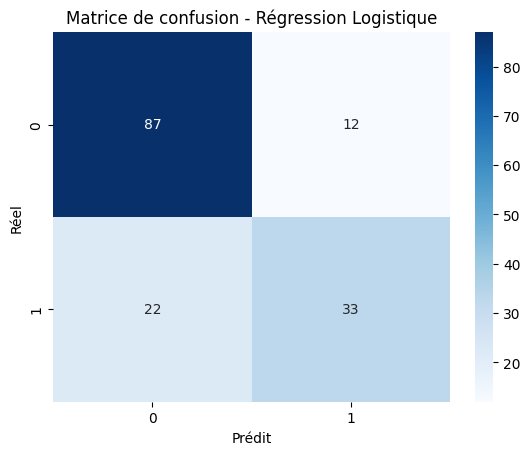

In [ ]:
from sklearn import metrics
import seaborn as sns
import matplotlib.pyplot as plt

cm = metrics.confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.title('Matrice de confusion - Régression Logistique')
plt.show()


In [ ]:
accuracy = metrics.accuracy_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
precision = metrics.precision_score(y_test, y_pred)
f1 = metrics.f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Recall :", recall)
print("Precision :", precision)
print("F1-score :", f1)


Accuracy : 0.7792207792207793
Recall : 0.6
Precision : 0.7333333333333333
F1-score : 0.66


In [ ]:
print(metrics.classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.80      0.88      0.84        99
           1       0.73      0.60      0.66        55

    accuracy                           0.78       154
   macro avg       0.77      0.74      0.75       154
weighted avg       0.78      0.78      0.77       154



In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier

models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(),
    "Random Forest": RandomForestClassifier(),
    "Decision Tree": DecisionTreeClassifier()
}

results = []
for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    acc = metrics.accuracy_score(y_test, y_pred)
    f1 = metrics.f1_score(y_test, y_pred)
    results.append([name, acc, f1])

df_results = pd.DataFrame(results, columns=["Modèle", "Accuracy", "F1-score"])
print(df_results.sort_values(by="F1-score", ascending=False))


                Modèle  Accuracy  F1-score
0  Logistic Regression  0.779221  0.660000
1                  KNN  0.753247  0.654545
3        Random Forest  0.740260  0.649123
2                  SVM  0.759740  0.633663
4        Decision Tree  0.707792  0.587156
